# 01 -- Exploration & Analyse descriptive
## VelibMMM -- Modele bayesien de disponibilite des stations

**Objectif :** charger les donnees historiques Velib (open data GitHub + snapshots GBFS),
nettoyer le fill_rate, explorer les patterns temporels et spatiaux.

**Sources :**
- Donnees historiques : `lovasoa/historique-velib-opendata` (GitHub releases)
- Snapshots temps reel : pipeline GBFS / GitHub Actions (parquet locaux)

---
### Plan
1. Chargement donnees historiques (GitHub)
2. Chargement & fusion snapshots GBFS locaux
3. Nettoyage & validation
4. Distribution du fill_rate
5. Patterns temporels
6. Analyse par station
7. Carte interactive
8. Export & synthese

## 0. Imports & configuration

In [1]:
import io, zipfile, gzip, requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import glob
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    "figure.dpi": 120, "figure.facecolor": "white",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.3, "font.size": 11,
})

ROOT     = Path('..').resolve()
SNAP_DIR = ROOT / 'data' / 'raw' / 'velib' / 'snapshots'
PROC_DIR = ROOT / 'data' / 'processed'
FIG_DIR  = ROOT / 'outputs' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)
PROC_DIR.mkdir(parents=True, exist_ok=True)

print('[OK] Imports OK')
print(f'ROOT     : {ROOT}')
print(f'SNAP_DIR : {SNAP_DIR}')
print(f'FIG_DIR  : {FIG_DIR}')

[OK] Imports OK
ROOT     : /Users/souhail/projets-ml/Velib-analytics
SNAP_DIR : /Users/souhail/projets-ml/Velib-analytics/data/raw/velib/snapshots
FIG_DIR  : /Users/souhail/projets-ml/Velib-analytics/outputs/figures


## 1. Chargement des donnees historiques (GitHub open data)

Le repo `lovasoa/historique-velib-opendata` contient l'historique complet
des stations Velib depuis 2018. On telecharge le CSV de la derniere release.

**Format :** ~10M lignes, colonnes : date, capacity, available_mechanical,
available_electrical, station_name, station_geo, operative

In [2]:
OWNER = 'lovasoa'
REPO  = 'historique-velib-opendata'

CANDIDATES = [
    f"https://github.com/{OWNER}/{REPO}/releases/latest/download/stations.zip",
    f"https://github.com/{OWNER}/{REPO}/releases/latest/download/stations.csv.zip",
    f"https://github.com/{OWNER}/{REPO}/releases/latest/download/stations.csv",
    f"https://github.com/{OWNER}/{REPO}/releases/latest/download/stations.csv.gz",
]

headers = {"User-Agent": "velib-notebook/1.0"}

def try_download(url):
    r = requests.get(url, headers=headers, timeout=60)
    if r.status_code == 200:
        return r
    return None

resp = None
chosen_url = None

print('Tentative de telechargement...')
for url in CANDIDATES:
    print(f'  Testing : {url.split("/")[-1]}', end=' ')
    resp = try_download(url)
    if resp:
        chosen_url = url
        print('[OK]')
        break
    print('[404]')

# Fallback : API GitHub pour trouver l'asset exact
if not resp:
    print('Fallback : interrogation API GitHub releases...')
    api = f"https://api.github.com/repos/{OWNER}/{REPO}/releases/latest"
    j = requests.get(api, headers=headers, timeout=60).json()
    assets = j.get("assets", [])
    for a in assets:
        name = a.get("name", "").lower()
        if "stations" in name and (name.endswith(".zip") or name.endswith(".csv") or name.endswith(".csv.gz")):
            chosen_url = a.get("browser_download_url")
            print(f'  Asset trouve : {a["name"]}')
            resp = requests.get(chosen_url, headers=headers, timeout=60)
            if resp.status_code == 200:
                break

if not resp:
    raise RuntimeError('Impossible de telecharger les donnees historiques.')

print(f'Telecharge depuis : {chosen_url}')
print(f'Taille : {len(resp.content)/1e6:.1f} MB')

Tentative de telechargement...
  Testing : stations.zip [OK]
Telecharge depuis : https://github.com/lovasoa/historique-velib-opendata/releases/latest/download/stations.zip
Taille : 236.0 MB


In [3]:
# Parsing du contenu selon le format
content = resp.content
df_hist = None

if chosen_url.endswith('.zip'):
    z = zipfile.ZipFile(io.BytesIO(content))
    csv_names = [n for n in z.namelist() if n.lower().endswith('.csv')]
    assert csv_names, 'Aucun CSV dans le zip.'
    print(f'CSV dans le zip : {csv_names}')
    df_hist = pd.read_csv(z.open(csv_names[0]), low_memory=False)

elif chosen_url.endswith('.csv.gz'):
    df_hist = pd.read_csv(io.BytesIO(gzip.decompress(content)), low_memory=False)

elif chosen_url.endswith('.csv'):
    df_hist = pd.read_csv(io.BytesIO(content), low_memory=False)

else:
    raise RuntimeError('Format inattendu : attendu .zip / .csv / .csv.gz')

print(f'[OK] Donnees historiques : {df_hist.shape}')
print(f'Colonnes : {df_hist.columns.tolist()}')
df_hist.head()

CSV dans le zip : ['historique_stations.csv']
[OK] Donnees historiques : (10986729, 7)
Colonnes : ['2020-11-26T12:59Z', '35', '4', '5', 'Benjamin Godard - Victor Hugo', '48.86598,2.27572', 'True']


,2020-11-26T12:59Z,35,4,5,Benjamin Godard - Victor Hugo,"48.86598,2.27572",True
0,2020-11-26T12:59Z,55,23,4,André Mazet - Saint-André des Arts,"48.85376,2.33910",True
1,2020-11-26T12:59Z,20,0,0,Charonne - Robert et Sonia Delauney,"48.85591,2.39257",True
2,2020-11-26T12:59Z,21,0,1,Toudouze - Clauzel,"48.87930,2.33736",True
3,2020-11-26T12:59Z,30,3,1,Mairie du 12ème,"48.84086,2.38755",True
4,2020-11-26T12:59Z,46,18,10,Harpe - Saint-Germain,"48.85152,2.34367",True


In [7]:
# Rechargement avec les bons noms de colonnes (pas de header dans ce CSV)
import io, zipfile, gzip

content = resp.content

if chosen_url.endswith('.zip'):
    z = zipfile.ZipFile(io.BytesIO(content))
    csv_names = [n for n in z.namelist() if n.lower().endswith('.csv')]
    df_hist = pd.read_csv(
        z.open(csv_names[0]),
        header=None,
        names=["ts_utc", "capacity", "available_mechanical", "available_ebike",
               "name", "station_geo", "operative"],
        low_memory=False
    )
elif chosen_url.endswith('.csv.gz'):
    df_hist = pd.read_csv(
        io.BytesIO(gzip.decompress(content)),
        header=None,
        names=["ts_utc", "capacity", "available_mechanical", "available_ebike",
               "name", "station_geo", "operative"],
        low_memory=False
    )
else:
    df_hist = pd.read_csv(
        io.BytesIO(content),
        header=None,
        names=["ts_utc", "capacity", "available_mechanical", "available_ebike",
               "name", "station_geo", "operative"],
        low_memory=False
    )

# Parsing date
df_hist['ts_utc'] = pd.to_datetime(df_hist['ts_utc'], utc=True, errors='coerce')

# Extraction lat/lon depuis station_geo (format "lat,lon")
try:
    coords = df_hist['station_geo'].str.extract(r'([\d.]+),\s*([\d.]+)')
    df_hist['lat'] = coords[0].astype(float)
    df_hist['lon'] = coords[1].astype(float)
    print('[OK] lat/lon extraits')
except Exception as e:
    print(f'[WARN] {e}')

# Conversion types numeriques
for col in ['capacity', 'available_mechanical', 'available_ebike']:
    df_hist[col] = pd.to_numeric(df_hist[col], errors='coerce')

# Calcul fill_rate
total_bikes = df_hist['available_mechanical'].fillna(0) + df_hist['available_ebike'].fillna(0)
df_hist['fill_rate'] = (total_bikes / df_hist['capacity'].replace(0, np.nan)).clip(0, 1)

# station_id = nom de la station (pas d'ID numerique dans ce dataset)
df_hist['station_id'] = df_hist['name']

print(f'Colonnes : {df_hist.columns.tolist()}')
print(f'Shape    : {df_hist.shape}')
print(f'Periode  : {df_hist["ts_utc"].min()} --> {df_hist["ts_utc"].max()}')
print(df_hist['fill_rate'].describe().round(3))
df_hist.head(3)

[OK] lat/lon extraits
Colonnes : ['ts_utc', 'capacity', 'available_mechanical', 'available_ebike', 'name', 'station_geo', 'operative', 'lat', 'lon', 'fill_rate', 'station_id']
Shape    : (10986730, 11)
Periode  : 2020-11-26 12:59:00+00:00 --> 2021-04-09 14:37:00+00:00
count    1.092197e+07
mean     3.630000e-01
std      2.670000e-01
min      0.000000e+00
25%      1.390000e-01
50%      3.000000e-01
75%      5.500000e-01
max      1.000000e+00
Name: fill_rate, dtype: float64


,ts_utc,capacity,available_mechanical,available_ebike,name,station_geo,operative,lat,lon,fill_rate,station_id
0,2020-11-26 12:59:00+00:00,35,4,5,Benjamin Godard - Victor Hugo,"48.86598,2.27572",True,48.86598,2.27572,0.257143,Benjamin Godard - Victor Hugo
1,2020-11-26 12:59:00+00:00,55,23,4,André Mazet - Saint-André des Arts,"48.85376,2.33910",True,48.85376,2.33910,0.490909,André Mazet - Saint-André des Arts
2,2020-11-26 12:59:00+00:00,20,0,0,Charonne - Robert et Sonia Delauney,"48.85591,2.39257",True,48.85591,2.39257,0.000000,Charonne - Robert et Sonia Delauney


## 2. Chargement des snapshots GBFS locaux

Le pipeline GitHub Actions produit ~1 snapshot/heure en parquet.
On les charge et on les fusionne avec les donnees historiques.
Ces snapshots sont la source **temps reel** du modele en production.

In [8]:
snapshots = sorted(glob.glob(str(SNAP_DIR / '*.parquet')))
print(f'{len(snapshots)} snapshots GBFS locaux disponibles')

df_snaps = None
if snapshots:
    dfs = []
    for path in snapshots:
        try:
            dfs.append(pd.read_parquet(path))
        except Exception as e:
            print(f'[WARN] {Path(path).name} : {e}')
    df_snaps = pd.concat(dfs, ignore_index=True)

    # Normalisation colonnes
    df_snaps['ts_utc'] = pd.to_datetime(df_snaps['ts_utc'], utc=True, errors='coerce')
    df_snaps['fill_rate'] = df_snaps['fill_rate'].clip(0, 1)

    print(f'[OK] Snapshots GBFS : {df_snaps.shape}')
    print(f'Periode : {df_snaps["ts_utc"].min()} --> {df_snaps["ts_utc"].max()}')
    print(f'Colonnes : {df_snaps.columns.tolist()}')
else:
    print('[INFO] Aucun snapshot local -- utilisation donnees historiques uniquement')

147 snapshots GBFS locaux disponibles
[OK] Snapshots GBFS : (220353, 24)
Periode : 2025-11-10 11:34:10.985346+00:00 --> 2025-11-13 11:30:30.954158+00:00
Colonnes : ['ts_utc', 'ts_local', 'id', 'name', 'lat', 'lon', 'capacity', 'num_bikes_available_norm', 'num_docks_available_norm', 'available_mechanical', 'available_ebike', 'is_installed', 'is_renting', 'is_returning', 'last_reported', 'fill_rate', 'station_id', 'num_bikes_available', 'numBikesAvailable', 'num_bikes_available_types', 'num_docks_available', 'numDocksAvailable', 'stationCode', 'station_opening_hours']


## 3. Dataset de travail -- fusion & nettoyage

On choisit la source principale selon la disponibilite :
- Historique GitHub : longue periode, toutes les 5min
- Snapshots GBFS : recent, toutes les heures

Pour le modele bayesien, on travaille principalement sur les **snapshots GBFS**
car ils ont la structure multi-colonnes necessaire (available_mechanical, available_ebike, etc.).

In [9]:
# Choix de la source principale
# On utilise les snapshots GBFS si disponibles (plus riches en colonnes)
# et les donnees historiques comme complementaire

if df_snaps is not None:
    df = df_snaps.copy()
    print('[OK] Source principale : snapshots GBFS locaux')
else:
    df = df_hist.copy()
    print('[OK] Source principale : donnees historiques GitHub')

# Colonnes utiles communes
COLS_KEEP = [
    'ts_utc', 'station_id', 'fill_rate',
    'num_bikes_available', 'num_docks_available',
    'available_mechanical', 'available_ebike',
    'capacity', 'lat', 'lon', 'name', 'is_installed',
]
cols_present = [c for c in COLS_KEEP if c in df.columns]
df = df[cols_present].copy()

# Filtrer stations actives
if 'is_installed' in df.columns:
    n_before = len(df)
    df = df[df['is_installed'].astype(bool)].copy()
    print(f'Stations inactives supprimees : {n_before - len(df)}')

# Clipper fill_rate
df['fill_rate'] = df['fill_rate'].clip(0, 1)
df = df.dropna(subset=['fill_rate', 'ts_utc']).copy()

# Features temporelles
df['hour']        = df['ts_utc'].dt.hour
df['day_of_week'] = df['ts_utc'].dt.dayofweek
df['date']        = df['ts_utc'].dt.date
df['is_weekend']  = df['day_of_week'] >= 5
df['week']        = df['ts_utc'].dt.isocalendar().week.astype(int)
df['is_rush']     = df['hour'].isin([7,8,9,17,18,19])

print(f'\n=== Dataset de travail ===')
print(f'Shape      : {df.shape}')
print(f'Stations   : {df["station_id"].nunique()}')
print(f'Snapshots  : {df["ts_utc"].nunique()}')
periode_min = str(df['ts_utc'].min())[:16]
periode_max = str(df['ts_utc'].max())[:16]
print(f'Periode    : {periode_min} --> {periode_max}')
fr_min = df['fill_rate'].min()
fr_max = df['fill_rate'].max()
fr_mean = df['fill_rate'].mean()
fr_std = df['fill_rate'].std()
print(f'fill_rate  : min={fr_min:.3f}  max={fr_max:.3f}  mean={fr_mean:.3f}  std={fr_std:.3f}')

[OK] Source principale : snapshots GBFS locaux
Stations inactives supprimees : 1467

=== Dataset de travail ===
Shape      : (218151, 18)
Stations   : 1485
Snapshots  : 147
Periode    : 2025-11-10 11:34 --> 2025-11-13 11:30
fill_rate  : min=0.000  max=1.000  mean=0.388  std=0.286


## 4. Distribution du fill_rate

`fill_rate` = proportion de velos disponibles dans la station.
C'est notre **variable reponse** dans le modele bayesien.
La distribution Beta est le modele naturel pour une variable continue en (0,1).

**Analogie MMM :** fill_rate joue le role du 'revenue' dans RobynMMM.

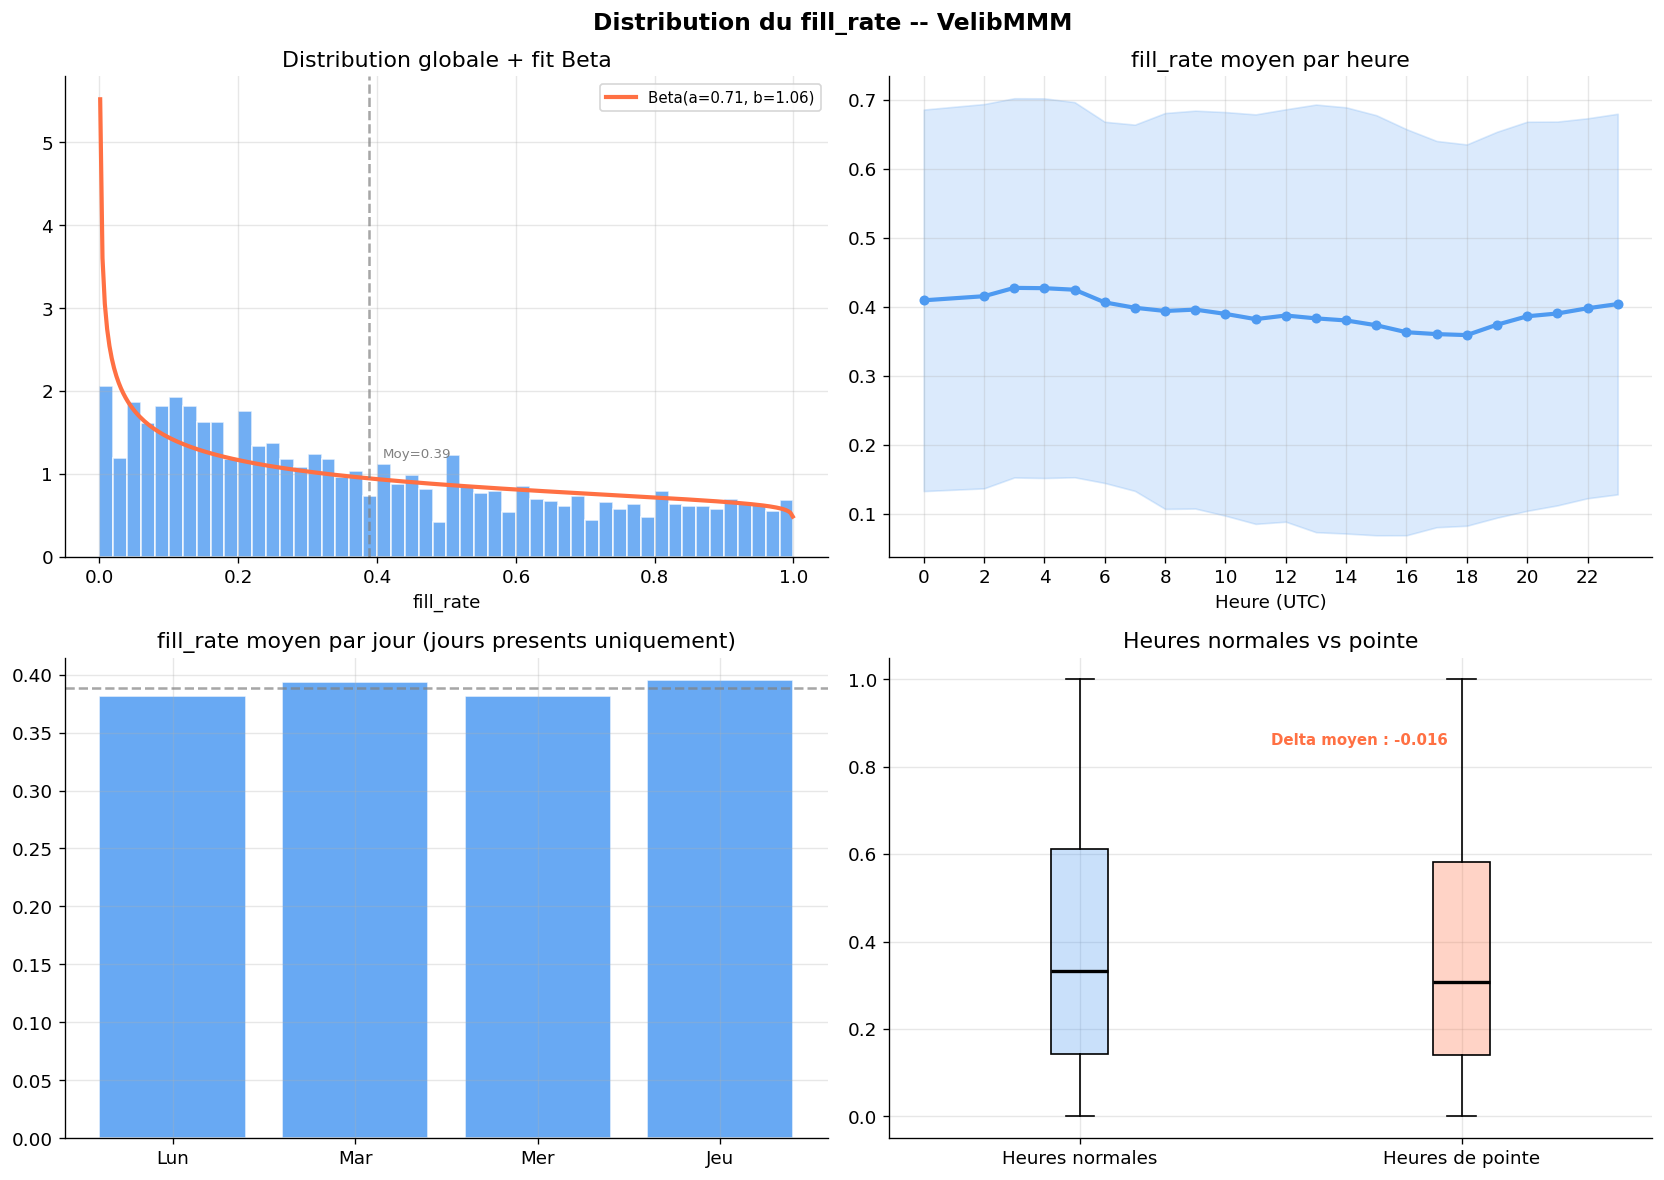

[OK] Figure sauvegardee
Fit Beta : alpha=0.710, beta=1.061
Mode=1.265  |  Moyenne theorique=0.401
=> Ces parametres seront les priors de la Beta regression PyMC (notebook 03)


In [11]:
from scipy import stats as scipy_stats

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Distribution du fill_rate -- VelibMMM', fontsize=14, fontweight='bold')

# Distribution globale + fit Beta
ax = axes[0, 0]
ax.hist(df['fill_rate'], bins=50, color='#4E9AF1', alpha=0.8, edgecolor='white', density=True)
x = np.linspace(0.001, 0.999, 300)
a_beta, b_beta, _, _ = scipy_stats.beta.fit(df['fill_rate'].clip(0.001, 0.999), floc=0, fscale=1)
ax.plot(x, scipy_stats.beta.pdf(x, a_beta, b_beta), color='#FF7043', linewidth=2.5,
        label=f'Beta(a={a_beta:.2f}, b={b_beta:.2f})')
ax.axvline(x=df['fill_rate'].mean(), color='gray', linestyle='--', alpha=0.7)
mean_fr = df['fill_rate'].mean()
ax.annotate(f'Moy={mean_fr:.2f}', xy=(mean_fr+0.02, 1.2), fontsize=8, color='gray')
ax.set_title('Distribution globale + fit Beta')
ax.set_xlabel('fill_rate')
ax.legend(fontsize=9)

# Par heure
ax2 = axes[0, 1]
hourly = df.groupby('hour')['fill_rate'].agg(['mean','std'])
ax2.plot(hourly.index, hourly['mean'], color='#4E9AF1', linewidth=2.5, marker='o', markersize=5)
ax2.fill_between(hourly.index, hourly['mean']-hourly['std'],
                 hourly['mean']+hourly['std'], alpha=0.2, color='#4E9AF1')
ax2.set_title('fill_rate moyen par heure')
ax2.set_xlabel('Heure (UTC)')
ax2.set_xticks(range(0, 24, 2))

# Par jour -- labels dynamiques selon les jours presents dans les donnees
ax3 = axes[1, 0]
all_day_labels = ['Lun','Mar','Mer','Jeu','Ven','Sam','Dim']
daily = df.groupby('day_of_week')['fill_rate'].mean()
day_labels_present = [all_day_labels[i] for i in daily.index]
colors_d = ['#FF7043' if i >= 5 else '#4E9AF1' for i in daily.index]
ax3.bar(day_labels_present, daily.values, color=colors_d, alpha=0.85, edgecolor='white')
ax3.axhline(y=daily.mean(), color='gray', linestyle='--', alpha=0.7)
ax3.set_title('fill_rate moyen par jour (jours presents uniquement)')

# Rush vs normal
ax4 = axes[1, 1]
rush_hours = [7, 8, 9, 17, 18, 19]
data_rush  = df[df['hour'].isin(rush_hours)]['fill_rate'].values
data_other = df[~df['hour'].isin(rush_hours)]['fill_rate'].values
if len(data_rush) > 0 and len(data_other) > 0:
    bp = ax4.boxplot([data_other, data_rush], patch_artist=True,
                     labels=['Heures normales','Heures de pointe'],
                     medianprops={'color':'black','linewidth':2})
    bp['boxes'][0].set_facecolor('#4E9AF14D')
    bp['boxes'][1].set_facecolor('#FF70434D')
    diff = data_rush.mean() - data_other.mean()
    diff_str = f'{diff:+.3f}'
    ax4.annotate(f'Delta moyen : {diff_str}', xy=(1.5, 0.85),
                 fontsize=9, color='#FF7043', fontweight='bold')
else:
    ax4.text(0.5, 0.5, 'Pas assez de donnees', ha='center', transform=ax4.transAxes)
ax4.set_title('Heures normales vs pointe')

plt.tight_layout()
plt.savefig(str(FIG_DIR / '01_fillrate_distribution.png'), bbox_inches='tight', dpi=150)
plt.show()
print('[OK] Figure sauvegardee')
mode_val = (a_beta-1)/(a_beta+b_beta-2)
mean_val = a_beta/(a_beta+b_beta)
print(f'Fit Beta : alpha={a_beta:.3f}, beta={b_beta:.3f}')
print(f'Mode={mode_val:.3f}  |  Moyenne theorique={mean_val:.3f}')
print(f'=> Ces parametres seront les priors de la Beta regression PyMC (notebook 03)')

## 5. Patterns temporels -- le signal de drainage

On cherche les **patterns de drainage** -- les moments ou les stations se vident.
Ce sont ces patterns qu'on va capturer avec l'**adstock drainage** (EMA) dans le notebook 02.

**Analogie MMM :** le drainage = adstock des sorties de velos, exactement comme
l'adstock TV capture la memoire d'une campagne publicitaire.

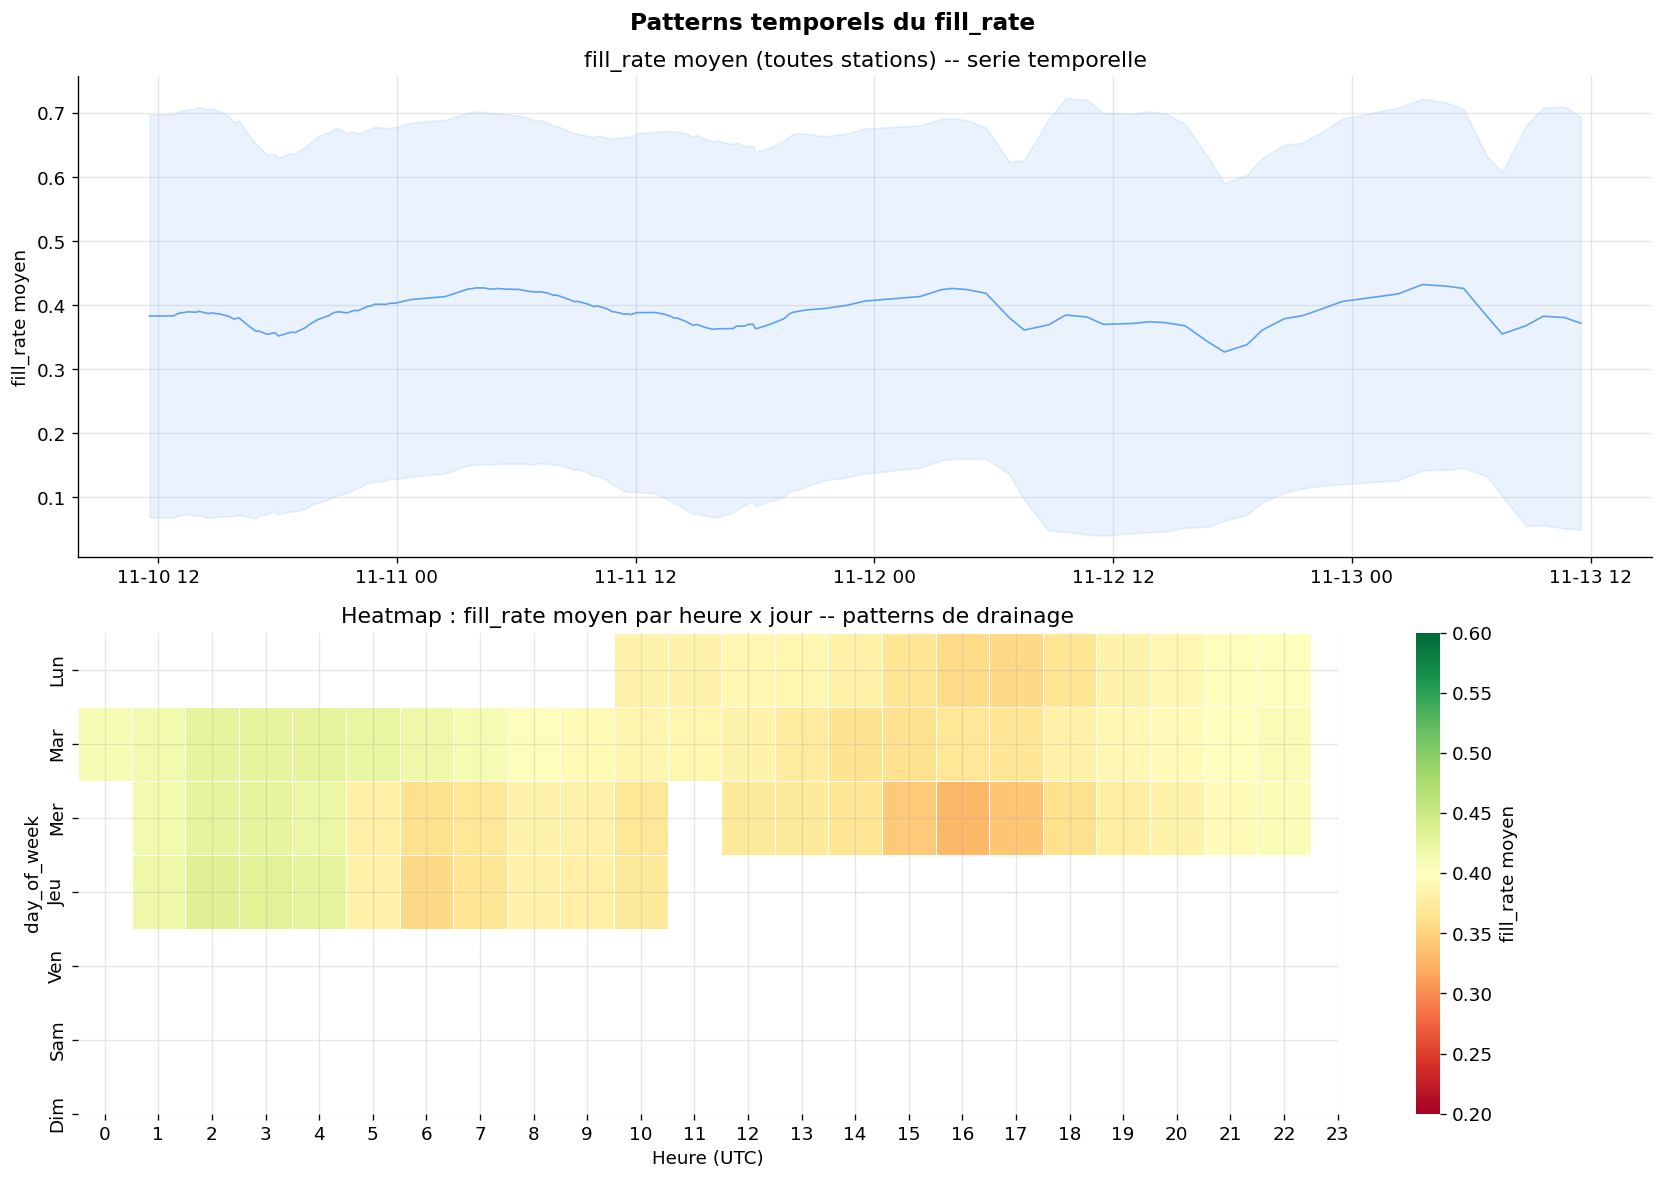

[OK] Figure sauvegardee


In [12]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle('Patterns temporels du fill_rate', fontsize=14, fontweight='bold')

# Serie temporelle globale
ax = axes[0]
ts_agg = df.groupby('ts_utc')['fill_rate'].agg(['mean','std']).reset_index()
ax.plot(ts_agg['ts_utc'], ts_agg['mean'], color='#4E9AF1', linewidth=1, alpha=0.9)
ax.fill_between(ts_agg['ts_utc'],
                ts_agg['mean'] - ts_agg['std'],
                ts_agg['mean'] + ts_agg['std'],
                alpha=0.12, color='#4E9AF1')
ax.set_title('fill_rate moyen (toutes stations) -- serie temporelle')
ax.set_ylabel('fill_rate moyen')

# Heatmap heure x jour
ax2 = axes[1]
pivot = df.groupby(['day_of_week','hour'])['fill_rate'].mean().unstack()
dow_labels = ['Lun','Mar','Mer','Jeu','Ven','Sam','Dim']
sns.heatmap(pivot, ax=ax2, cmap='RdYlGn', vmin=0.2, vmax=0.6,
            xticklabels=range(0,24), yticklabels=dow_labels,
            cbar_kws={'label':'fill_rate moyen'}, linewidths=0.3)
ax2.set_title('Heatmap : fill_rate moyen par heure x jour -- patterns de drainage')
ax2.set_xlabel('Heure (UTC)')

plt.tight_layout()
plt.savefig(str(FIG_DIR / '01_patterns_temporels.png'), bbox_inches='tight', dpi=150)
plt.show()
print('[OK] Figure sauvegardee')

## 6. Analyse par station

In [13]:
agg_dict = {'fill_rate': ['mean','std','min','max','count'], 'lat': 'first', 'lon': 'first'}
if 'name' in df.columns:
    agg_dict['name'] = 'first'

station_stats = df.groupby('station_id').agg(agg_dict)
col_names = ['fr_mean','fr_std','fr_min','fr_max','n_obs','lat','lon']
if 'name' in df.columns:
    col_names.append('name')
station_stats.columns = col_names
station_stats = station_stats.reset_index()
station_stats['cv'] = station_stats['fr_std'] / station_stats['fr_mean'].replace(0, np.nan)

print('=== Top 10 stations les plus variables (CV) ===')
top10 = station_stats.nlargest(10, 'cv')[['station_id','fr_mean','fr_std','cv','n_obs']]
print(top10.to_string(index=False))

n_empty = len(station_stats[station_stats['fr_mean'] < 0.1])
n_full  = len(station_stats[station_stats['fr_mean'] > 0.9])
n_total = len(station_stats)
print(f'\nStations souvent vides   (fr<0.1) : {n_empty} ({n_empty/n_total*100:.1f}%)')
print(f'Stations souvent pleines (fr>0.9) : {n_full}  ({n_full/n_total*100:.1f}%)')
print(f'Stations moderees        (reste)  : {n_total - n_empty - n_full}')

=== Top 10 stations les plus variables (CV) ===
 station_id  fr_mean   fr_std       cv  n_obs
   42499285 0.095238 0.264570 2.777984    147
  210573120 0.025562 0.068102 2.664227    147
16659964929 0.022519 0.058716 2.607336    147
   15383032 0.109899 0.272096 2.475869    147
  224256188 0.017359 0.041429 2.386664    147
   54000555 0.116202 0.275897 2.374295    147
   66491389 0.094183 0.220745 2.343796    147
  128932790 0.035322 0.080842 2.288726    147
   82337423 0.068606 0.156426 2.280053    147
   27415411 0.075126 0.137731 1.833341    147

Stations souvent vides   (fr<0.1) : 57 (3.8%)
Stations souvent pleines (fr>0.9) : 7  (0.5%)
Stations moderees        (reste)  : 1421


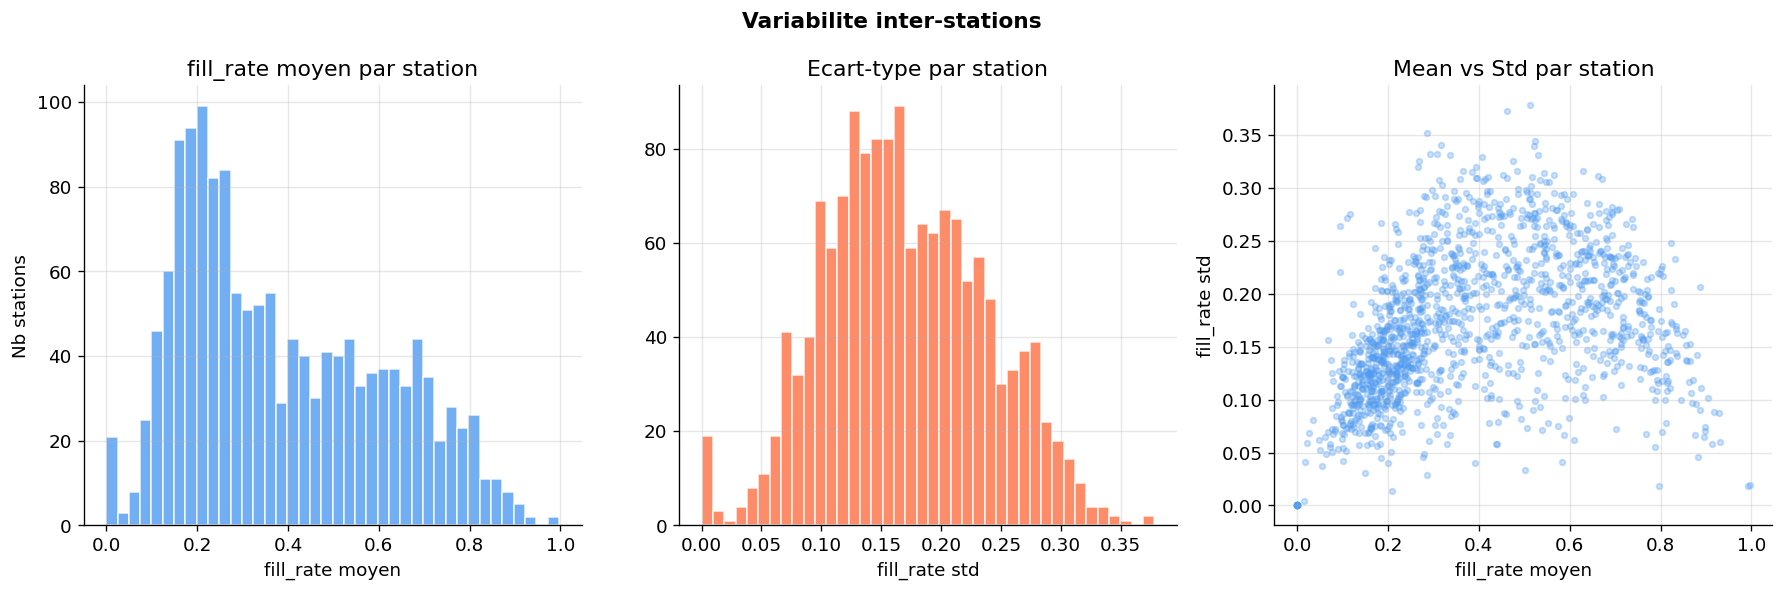

[OK] Figure sauvegardee


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Variabilite inter-stations', fontsize=13, fontweight='bold')

axes[0].hist(station_stats['fr_mean'], bins=40, color='#4E9AF1', alpha=0.8, edgecolor='white')
axes[0].set_title('fill_rate moyen par station')
axes[0].set_xlabel('fill_rate moyen')
axes[0].set_ylabel('Nb stations')

axes[1].hist(station_stats['fr_std'], bins=40, color='#FF7043', alpha=0.8, edgecolor='white')
axes[1].set_title('Ecart-type par station')
axes[1].set_xlabel('fill_rate std')

axes[2].scatter(station_stats['fr_mean'], station_stats['fr_std'],
                alpha=0.3, s=12, color='#4E9AF1')
axes[2].set_xlabel('fill_rate moyen')
axes[2].set_ylabel('fill_rate std')
axes[2].set_title('Mean vs Std par station')

plt.tight_layout()
plt.savefig(str(FIG_DIR / '01_variabilite_stations.png'), bbox_inches='tight', dpi=150)
plt.show()
print('[OK] Figure sauvegardee')

## 7. Carte interactive des stations

Chaque station est coloree selon son fill_rate moyen.
Les stations rouges sont souvent vides -- candidates prioritaires pour le modele de prediction.

In [15]:
try:
    import folium

    m = folium.Map(location=[48.8566, 2.3522], zoom_start=13, tiles='CartoDB positron')

    def color_fr(fr):
        if fr < 0.2:   return '#FF4444'
        elif fr < 0.4: return '#FF9944'
        elif fr < 0.6: return '#FFD700'
        elif fr < 0.8: return '#88CC44'
        else:          return '#22AA22'

    for _, row in station_stats.iterrows():
        if pd.isna(row['lat']) or pd.isna(row['lon']):
            continue
        nm = row['name'] if 'name' in station_stats.columns else str(row['station_id'])
        popup_txt = (
            f'<b>{nm}</b><br>ID: {row["station_id"]}<br>'
            f'fill_rate moy: {row["fr_mean"]:.2f}<br>'
            f'std: {row["fr_std"]:.2f}<br>n_obs: {int(row["n_obs"])}'
        )
        folium.CircleMarker(
            location=[row['lat'], row['lon']],
            radius=4,
            color=color_fr(row['fr_mean']),
            fill=True, fill_opacity=0.75, weight=0.5,
            popup=folium.Popup(popup_txt, max_width=200)
        ).add_to(m)

    legend = (
        '<div style="position:fixed;bottom:30px;left:30px;z-index:1000;'
        'background:white;padding:10px;border-radius:8px;'
        'border:1px solid #ccc;font-size:12px;">'
        '<b>fill_rate moyen</b><br>'
        '<span style="color:#FF4444">&#9679;</span> &lt; 0.2 (vide)<br>'
        '<span style="color:#FF9944">&#9679;</span> 0.2 - 0.4<br>'
        '<span style="color:#FFD700">&#9679;</span> 0.4 - 0.6<br>'
        '<span style="color:#88CC44">&#9679;</span> 0.6 - 0.8<br>'
        '<span style="color:#22AA22">&#9679;</span> &gt; 0.8 (plein)</div>'
    )
    m.get_root().html.add_child(folium.Element(legend))
    map_path = str(FIG_DIR / '01_carte_stations.html')
    m.save(map_path)
    print(f'[OK] Carte : outputs/figures/01_carte_stations.html')
    print(f'     {len(station_stats)} stations cartographiees')
    m

except ImportError:
    print('[WARN] folium non installe -- pip install folium')

[WARN] folium non installe -- pip install folium


## 8. Export du dataset nettoye

In [16]:
df.to_parquet(PROC_DIR / 'velib_clean.parquet', index=False)
station_stats.to_parquet(PROC_DIR / 'station_stats.parquet', index=False)

print(f'[OK] velib_clean.parquet   : {df.shape[0]:,} lignes x {df.shape[1]} colonnes')
print(f'[OK] station_stats.parquet : {len(station_stats)} stations')
print('\nColonnes exportees :')
for c in df.columns:
    print(f'  {c}')

[OK] velib_clean.parquet   : 218,151 lignes x 18 colonnes
[OK] station_stats.parquet : 1485 stations

Colonnes exportees :
  ts_utc
  station_id
  fill_rate
  num_bikes_available
  num_docks_available
  available_mechanical
  available_ebike
  capacity
  lat
  lon
  name
  is_installed
  hour
  day_of_week
  date
  is_weekend
  week
  is_rush


## 9. Synthese & insights cles

In [17]:
print('=' * 65)
print('  SYNTHESE EDA -- VelibMMM')
print('=' * 65)

n_snap     = len(snapshots)
n_stations = df['station_id'].nunique()
n_obs      = len(df)
fr_mean_s  = df['fill_rate'].mean()
fr_std_s   = df['fill_rate'].std()
pct_empty  = (df['fill_rate'] < 0.1).mean() * 100
pct_full   = (df['fill_rate'] > 0.9).mean() * 100
rush_delta = data_rush.mean() - data_other.mean()
d_min      = str(df['ts_utc'].min())[:10]
d_max      = str(df['ts_utc'].max())[:10]

print(f'DONNEES')
print(f'  Snapshots GBFS locaux  : {n_snap}')
print(f'  Stations               : {n_stations}')
print(f'  Observations           : {n_obs:,}')
print(f'  Periode                : {d_min} -- {d_max}')
print()
print(f'FILL_RATE (variable reponse)')
print(f'  Moyenne                : {fr_mean_s:.3f}')
print(f'  Ecart-type             : {fr_std_s:.3f}')
print(f'  Fit Beta               : alpha={a_beta:.2f}, beta={b_beta:.2f}')
print(f'  Stations vides (<0.1)  : {pct_empty:.1f}%')
print(f'  Stations pleines (>0.9): {pct_full:.1f}%')
print()
print(f'PATTERNS TEMPORELS')
rush_delta_str = f'{rush_delta:+.3f}'
print(f'  Rush vs normal         : delta {rush_delta_str}')
print(f'  Heatmap jour x heure   : patterns de drainage clairs')
print()
print('PROCHAINE ETAPE --> Notebook 02 : Feature engineering')
print('  - Target      : fill_rate(t+30min) par station')
print('  - Adstock     : EMA du drainage (analogie adstock TV)')
print('  - Features    : hour_sin/cos, is_rush, is_weekend, rain')
print('  - Voisinage   : drainage moyen des N stations proches')
print('  - MCMC (NB 03): Beta regression bayesienne avec PyMC')
print('=' * 65)

  SYNTHESE EDA -- VelibMMM
DONNEES
  Snapshots GBFS locaux  : 147
  Stations               : 1485
  Observations           : 218,151
  Periode                : 2025-11-10 -- 2025-11-13

FILL_RATE (variable reponse)
  Moyenne                : 0.388
  Ecart-type             : 0.286
  Fit Beta               : alpha=0.71, beta=1.06
  Stations vides (<0.1)  : 17.1%
  Stations pleines (>0.9): 6.1%

PATTERNS TEMPORELS
  Rush vs normal         : delta -0.016
  Heatmap jour x heure   : patterns de drainage clairs

PROCHAINE ETAPE --> Notebook 02 : Feature engineering
  - Target      : fill_rate(t+30min) par station
  - Adstock     : EMA du drainage (analogie adstock TV)
  - Features    : hour_sin/cos, is_rush, is_weekend, rain
  - Voisinage   : drainage moyen des N stations proches
  - MCMC (NB 03): Beta regression bayesienne avec PyMC
